<a href="https://colab.research.google.com/github/JillianYano/first_assignment/blob/main/Copy_of_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#  SMART RESUME ↔ JOB MATCHER  (Full Rewrite)
#  Teacher requirements:
#   1. Verify "true skills" with proficiency levels
#   2. Weight top 5 skills per job (they matter most)
#   3. Weighted scoring formula (not just keyword count)
#   4. Value vs Process job type tagging
#   5. Separate ranking logic per job type
# ============================================================

# ── CELL 1: Mount Drive & Imports ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

# ── CELL 2: Load Data ──────────────────────────────────────
df_posting = pd.read_csv('/content/drive/MyDrive/121_data/Copy of postings.csv')
df_resume  = pd.read_csv('/content/drive/MyDrive/121_data/Copy of Resume.csv')




Mounted at /content/drive


In [ ]:
print("Postings shape:", df_posting.shape)
print("Resumes shape: ", df_resume.shape)

# ── CELL 3: Basic Cleaning ─────────────────────────────────
df_posting_clean = df_posting[['job_id','company_name','title','description','skills_desc']].copy()
df_posting_clean = df_posting_clean.dropna(subset=['company_name','title'])

df_resume_clean = df_resume[['ID','Resume_str','Category']].copy()

print("Clean postings:", df_posting_clean.shape)
print("Clean resumes: ", df_resume_clean.shape)

# ── CELL 4: Expanded Skills with Synonyms (REPLACE) ───────
# Each entry: (canonical_name, [patterns_to_match])
SKILL_SYNONYMS = {
    # Technical
    "python":             ["python"],
    "sql":                ["sql", "mysql", "postgresql", "postgres", "t-sql", "pl/sql", "sequel"],
    "excel":              ["excel", "microsoft excel", "ms excel", "spreadsheet"],
    "java":               ["java"],
    "c++":                ["c++", "c plus plus"],
    "machine learning":   ["machine learning", "ml model", "predictive model"],
    "deep learning":      ["deep learning", "neural network", "cnn", "rnn", "lstm"],
    "data analysis":      ["data analysis", "data analytics", "analyzing data", "data analyst"],
    "statistics":         ["statistics", "statistical", "regression", "hypothesis"],
    "tableau":            ["tableau"],
    "power bi":           ["power bi", "powerbi"],
    "aws":                ["aws", "amazon web services", "ec2", "s3 bucket"],
    "docker":             ["docker", "containerization", "kubernetes", "k8s"],
    "linux":              ["linux", "unix", "bash", "shell scripting"],
    "git":                ["git", "github", "gitlab", "version control"],
    "pandas":             ["pandas"],
    "numpy":              ["numpy"],
    "tensorflow":         ["tensorflow", "keras"],
    "scikit learn":       ["scikit learn", "scikit-learn", "sklearn"],
    "matlab":             ["matlab"],
    "spark":              ["spark", "apache spark", "pyspark"],
    "hadoop":             ["hadoop", "hdfs", "hive", "hbase"],
    "nlp":                ["nlp", "natural language processing", "text mining"],
    "data visualization": ["data visualization", "data viz", "visualization", "charts", "dashboards"],
    "javascript":         ["javascript", "js", "node.js", "nodejs", "typescript"],
    "html":               ["html", "html5"],
    "css":                ["css", "css3"],
    "react":              ["react", "reactjs", "react.js"],
    "mongodb":            ["mongodb", "nosql", "mongo"],
    "cybersecurity":      ["cybersecurity", "cyber security", "information security", "infosec", "siem"],
    "cloud":              ["cloud", "cloud computing", "saas", "iaas", "paas"],
    "azure":              ["azure", "microsoft azure"],
    "gcp":                ["gcp", "google cloud"],
    "figma":              ["figma", "sketch", "adobe xd"],
    "photoshop":          ["photoshop", "adobe photoshop", "illustrator", "indesign", "adobe creative"],
    # Business / Soft
    "communication":      ["communication", "written communication", "verbal communication", "interpersonal"],
    "project management": ["project management", "project manager", "pmp", "jira", "asana", "monday.com"],
    "leadership":         ["leadership", "team lead", "team leader", "managing teams", "people management"],
    "marketing":          ["marketing", "digital marketing", "content marketing", "seo", "sem", "social media marketing"],
    "sales":              ["sales", "b2b sales", "b2c sales", "salesforce", "crm", "account executive"],
    "customer service":   ["customer service", "customer support", "client relations", "customer success"],
    "accounting":         ["accounting", "accounts payable", "accounts receivable", "bookkeeping", "gaap"],
    "financial analysis": ["financial analysis", "financial modeling", "financial reporting", "fp&a"],
    "budgeting":          ["budgeting", "budget management", "cost management", "forecasting"],
    "business analysis":  ["business analysis", "business analyst", "requirements gathering", "process improvement"],
    "business intelligence": ["business intelligence", "bi developer", "bi analyst", "reporting"],
    "agile":              ["agile", "scrum", "sprint", "kanban", "sdlc"],
    "product management": ["product management", "product manager", "product owner", "roadmap"],
    "powerpoint":         ["powerpoint", "microsoft powerpoint", "presentations", "google slides"],
    "word":               ["microsoft word", "ms word", "google docs", "documentation"],
    "strategic planning": ["strategic planning", "strategy", "go-to-market", "business strategy"],
    "networking":         ["networking", "cisco", "vpn", "tcp/ip", "firewall", "lan", "wan"],
    "ux":                 ["ux", "user experience", "usability", "user research", "wireframe"],
    "ui":                 ["ui", "user interface", "front end", "frontend"],
    "data science":       ["data science", "data scientist"],
    "r":                  ["\\br\\b", "r programming", "rstudio"],
}

ALL_SKILLS = list(SKILL_SYNONYMS.keys())
print(f"Total canonical skills: {len(ALL_SKILLS)}")

# ── CELL 5: Text Cleaner ───────────────────────────────────
def clean_text(text):
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Postings shape: (123849, 31)
Resumes shape:  (2484, 4)
Clean postings: (122130, 5)
Clean resumes:  (2484, 3)
Total canonical skills: 56


In [ ]:


# ── CELL 6: Skill Frequency Counter ───────────────────────
# Instead of True/False, count how many times a skill appears
# in resume text → proxy for proficiency / depth of experience

def extract_skills_with_frequency(text, skill_list=ALL_SKILLS):
    """
    Returns a dict: {skill: frequency_count}
    More mentions = stronger signal of true skill.
    """
    text = " " + clean_text(text) + " "
    skill_freq = {}
    for skill in skill_list:
        pattern = r'\b' + re.escape(skill) + r'\b'
        matches = re.findall(pattern, text)
        if matches:
            skill_freq[skill] = len(matches)
    return skill_freq

# ── CELL 7: Apply to Resumes ───────────────────────────────
df_resume_clean["skill_freq"] = df_resume_clean["Resume_str"].apply(
    extract_skills_with_frequency
)

# Derive simple skill list for display
df_resume_clean["skills"] = df_resume_clean["skill_freq"].apply(
    lambda d: list(d.keys())
)

print("Sample resume skills with frequency:")
print(df_resume_clean[["ID","skills"]].head(3))

Sample resume skills with frequency:
         ID                                             skills
0  16852973  [data analysis, statistics, leadership, market...
1  22323967  [photoshop, communication, project management,...
2  33176873  [excel, project management, leadership, market...


In [ ]:
# ── CELL 8: Pure Pandas No-Loop (TRULY FAST) ───────────────

import re
import pandas as pd

df_posting_clean = df_posting_clean.reset_index(drop=True)

# Pre-clean entire column at once — pure C speed
print("Cleaning text...")
desc_clean = (
    df_posting_clean["description"]
    .fillna("")
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
)

print(f"Done. Building skill matrix for {len(desc_clean)} jobs...")

# For each skill, check entire column at once — no Python loop over rows
# This builds a DataFrame where each column = one skill, each row = count
skill_matrix = {}

for skill, synonyms in SKILL_SYNONYMS.items():
    pattern = '|'.join(re.escape(s) for s in synonyms)
    # str.contains checks all 122k rows in one C call
    skill_matrix[skill] = desc_clean.str.count(pattern).astype('int8')

print("Building skill matrix done. Converting to dicts...")

# Convert matrix to list of dicts, dropping zeros
skill_df = pd.DataFrame(skill_matrix)
df_posting_clean["skill_freq"] = [
    {col: int(val) for col, val in row.items() if val > 0}
    for row in skill_df.to_dict('records')
]
df_posting_clean["skills"] = df_posting_clean["skill_freq"].apply(list)

# Verify
skill_counts = df_posting_clean["skill_freq"].apply(len)
print("\nSkill count per job AFTER fix:")
print(skill_counts.describe())
print("Jobs with 0 skills: ", (skill_counts == 0).sum())
print("Jobs with 1 skill:  ", (skill_counts == 1).sum())
print("Jobs with 3+ skills:", (skill_counts >= 3).sum())
print("\nSample:", df_posting_clean["skill_freq"].iloc[0])

Cleaning text...
Done. Building skill matrix for 122130 jobs...
Building skill matrix done. Converting to dicts...

Skill count per job AFTER fix:
count    122130.000000
mean          5.779776
std           3.090136
min           0.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          35.000000
Name: skill_freq, dtype: float64
Jobs with 0 skills:  1138
Jobs with 1 skill:   4293
Jobs with 3+ skills: 107184

Sample: {'cloud': 1, 'photoshop': 4, 'marketing': 8, 'sales': 1, 'strategic planning': 1, 'networking': 2, 'ui': 1}


In [ ]:
# ── CELL 9: Weighted Skills (FIXED) ───────────────────────
# Key fix: if a job only has 1-2 skills detected, it's not
# enough signal — we penalize low-signal jobs in scoring instead
# of letting them score 1.0 by default.

def get_job_weighted_skills(skill_freq_dict, top_n=5):
    if not skill_freq_dict:
        return {}

    sorted_skills = sorted(skill_freq_dict.items(), key=lambda x: x[1], reverse=True)
    weighted = {}
    for i, (skill, _) in enumerate(sorted_skills):
        if i < top_n:
            weighted[skill] = 3
        elif i < top_n * 2:
            weighted[skill] = 2
        else:
            weighted[skill] = 1
    return weighted

df_posting_clean["weighted_skills"] = df_posting_clean["skill_freq"].apply(
    get_job_weighted_skills
)

# ── NEW: Flag low-signal jobs (fewer than 3 skills detected)
df_posting_clean["skill_signal"] = df_posting_clean["skill_freq"].apply(
    lambda d: "low" if len(d) < 3 else "ok"
)
print("Low signal jobs:", (df_posting_clean["skill_signal"] == "low").sum())
print("OK signal jobs: ", (df_posting_clean["skill_signal"] == "ok").sum())

Low signal jobs: 14946
OK signal jobs:  107184


In [ ]:
# ── CELL 9: Auto-Detect Top 5 Skills Per Job ──────────────
# Skills mentioned most frequently in a job posting = top priority
# These get weight 3 (critical). Next tier gets 2. Rest get 1.

def get_job_weighted_skills(skill_freq_dict, top_n=5):
    """
    Returns a dict: {skill: weight}
    Top N skills by frequency → weight 3
    Next N skills → weight 2
    Remaining → weight 1
    """
    if not skill_freq_dict:
        return {}

    sorted_skills = sorted(skill_freq_dict.items(), key=lambda x: x[1], reverse=True)
    weighted = {}

    for i, (skill, _) in enumerate(sorted_skills):
        if i < top_n:
            weighted[skill] = 3      # Critical / top priority
        elif i < top_n * 2:
            weighted[skill] = 2      # Important
        else:
            weighted[skill] = 1      # Nice to have

    return weighted

df_posting_clean["weighted_skills"] = df_posting_clean["skill_freq"].apply(
    get_job_weighted_skills
)

print("\nSample weighted skills for first job:")
print(df_posting_clean["weighted_skills"].iloc[0])


Sample weighted skills for first job:
{'marketing': 3, 'photoshop': 3, 'networking': 3, 'cloud': 3, 'sales': 3, 'strategic planning': 2, 'ui': 2}


In [ ]:


# ── CELL 10: Job Type Tagger (Value vs Process) ────────────
# VALUE jobs: care about outcomes, revenue, impact, leadership
# PROCESS jobs: care about tools, methodology, technical execution

VALUE_KEYWORDS = [
    'revenue','sales','growth','roi','profit','strategy','leadership',
    'stakeholder','business development','client','customer success',
    'pipeline','quota','account','negotiation','kpi','budget','p&l',
    'market share','brand','partnerships','executive'
]

PROCESS_KEYWORDS = [
    'pipeline','etl','architecture','infrastructure','deploy','ci/cd',
    'algorithm','model','query','database','api','framework','library',
    'testing','debugging','code','programming','engineer','developer',
    'analyst','data','implementation','configuration','technical',
    'automation','integration','workflow','schema','compute','docker'
]

def tag_job_type(description):
    text = clean_text(str(description))
    value_score   = sum(1 for kw in VALUE_KEYWORDS   if kw in text)
    process_score = sum(1 for kw in PROCESS_KEYWORDS if kw in text)

    if value_score > process_score:
        return "VALUE"
    elif process_score > value_score:
        return "PROCESS"
    else:
        return "BALANCED"

df_posting_clean["job_type"] = df_posting_clean["description"].apply(tag_job_type)

print("\nJob type distribution:")
print(df_posting_clean["job_type"].value_counts())


Job type distribution:
job_type
VALUE       54573
PROCESS     45760
BALANCED    21797
Name: count, dtype: int64


In [ ]:

# ── CELL 11: Resume Type Tagger ────────────────────────────
# Same idea for resumes — is this candidate results-oriented or tool-heavy?

VALUE_RESUME_KEYWORDS = [
    'increased','grew','generated','drove','led','managed','achieved',
    'delivered','exceeded','revenue','profit','reduced','saved','improved',
    'launched','won','negotiated','closed','built'
]

PROCESS_RESUME_KEYWORDS = [
    'developed','implemented','designed','built','coded','engineered',
    'analyzed','processed','automated','deployed','configured','integrated',
    'optimized','tested','debugged','maintained','documented'
]

def tag_resume_type(resume_text):
    text = clean_text(str(resume_text))
    value_score   = sum(1 for kw in VALUE_RESUME_KEYWORDS   if kw in text)
    process_score = sum(1 for kw in PROCESS_RESUME_KEYWORDS if kw in text)

    if value_score > process_score:
        return "VALUE"
    elif process_score > value_score:
        return "PROCESS"
    else:
        return "BALANCED"

df_resume_clean["resume_type"] = df_resume_clean["Resume_str"].apply(tag_resume_type)

print("\nResume type distribution:")
print(df_resume_clean["resume_type"].value_counts())


Resume type distribution:
resume_type
VALUE       1320
PROCESS      652
BALANCED     512
Name: count, dtype: int64


In [ ]:
# ── CELL 12: CORE — Weighted Skill Match (FIXED) ──────────

def weighted_skill_match(resume_skill_freq, job_weighted_skills, min_skills=3):
    """
    Fixed version:
    - Jobs with fewer than min_skills detected skills get capped at 0.5
      (not enough info to call it a real match)
    - Candidate must match at least 2 skills to score above 0
    """
    if not job_weighted_skills:
        return 0.0

    # Penalize jobs we couldn't extract enough signal from
    if len(job_weighted_skills) < min_skills:
        # Only give partial credit — we can't trust this match
        matched = set(resume_skill_freq.keys()) & set(job_weighted_skills.keys())
        return round(0.3 * (len(matched) / len(job_weighted_skills)), 4)

    total_possible = sum(job_weighted_skills.values())
    earned = 0
    matched_count = 0

    for skill, job_weight in job_weighted_skills.items():
        if skill in resume_skill_freq:
            freq_bonus = min(resume_skill_freq[skill], 3)
            earned += job_weight * (freq_bonus / 3)
            matched_count += 1

    # Require at least 2 skill matches to score meaningfully
    if matched_count < 2:
        return round((earned / total_possible) * 0.4, 4)

    return round(earned / total_possible, 4)

In [ ]:


# ── CELL 13: Type-Aware Scoring Bonus ─────────────────────
# If the resume type matches the job type → small bonus
# A VALUE resume applying to VALUE job = better cultural fit

def type_alignment_bonus(resume_type, job_type):
    """Returns a small bonus multiplier"""
    if resume_type == job_type:
        return 1.10   # 10% boost for alignment
    elif "BALANCED" in (resume_type, job_type):
        return 1.05   # 5% boost if either is balanced
    else:
        return 1.00   # no boost for mismatch

# ── CELL 14: Full Recommend Function ──────────────────────

def recommend_jobs(resume_index, top_n=10, job_type_filter=None):
    """
    Smart job recommender with:
      - Weighted skill matching (top 5 skills matter most)
      - Frequency-based skill confidence
      - Value vs Process alignment bonus

    Parameters:
      resume_index    : row index in df_resume_clean
      top_n           : how many jobs to return
      job_type_filter : None = all, "VALUE", "PROCESS", or "BALANCED"
    """

    resume_row        = df_resume_clean.iloc[resume_index]
    resume_skill_freq = resume_row["skill_freq"]
    resume_type       = resume_row["resume_type"]
    resume_id         = resume_row["ID"]
    resume_category   = resume_row["Category"]

    print(f"\n{'='*60}")
    print(f"Resume #{resume_id}  |  Category: {resume_category}")
    print(f"Resume Type: {resume_type}")
    print(f"Skills found: {list(resume_skill_freq.keys())}")
    print(f"{'='*60}\n")

    jobs = df_posting_clean.copy()

    # Optional filter by job type
    if job_type_filter:
        jobs = jobs[jobs["job_type"] == job_type_filter]

    # Score each job
    scores = []
    for _, job_row in jobs.iterrows():
        base_score = weighted_skill_match(
            resume_skill_freq,
            job_row["weighted_skills"]
        )
        bonus      = type_alignment_bonus(resume_type, job_row["job_type"])
        final_score = min(base_score * bonus, 1.0)  # cap at 100%
        scores.append(round(final_score, 4))

    jobs = jobs.copy()
    jobs["match_score"] = scores

    result = jobs.sort_values("match_score", ascending=False)[
        ["company_name","title","job_type","match_score","weighted_skills"]
    ].head(top_n)

    result["top_5_skills"] = result["weighted_skills"].apply(
        lambda d: [k for k,v in sorted(d.items(), key=lambda x: -x[1]) if v==3][:5]
    )

    return result[["company_name","title","job_type","match_score","top_5_skills"]]

In [ ]:



# ── CELL 15: Interactive Skill Verifier ───────────────────
# Teacher requirement: "ask what are TRUE skills"
# This lets you manually set a candidate's real skill confidence
# instead of relying only on keyword counting

def verify_and_override_skills(resume_index, manual_skill_ratings=None):
    """
    manual_skill_ratings: dict {skill_name: rating_1_to_3}
      1 = beginner, 2 = intermediate, 3 = expert

    If None, prompts user for each detected skill interactively.

    Returns updated skill_freq dict with overridden values.
    """
    resume_row        = df_resume_clean.iloc[resume_index]
    detected_skills   = resume_row["skill_freq"]

    if manual_skill_ratings is not None:
        # Merge: manual ratings override auto-detected frequency
        updated = detected_skills.copy()
        updated.update(manual_skill_ratings)
        return updated

    # Interactive mode
    print(f"\nDetected skills for Resume {resume_row['ID']}:")
    print("Rate each skill: 1=Beginner, 2=Intermediate, 3=Expert")
    print("Press Enter to keep auto-detected rating, or type 0 to remove skill.\n")

    updated = {}
    for skill, freq in detected_skills.items():
        auto_rating = min(freq, 3)
        try:
            user_input = input(f"  {skill} (auto={auto_rating}): ").strip()
            if user_input == "":
                updated[skill] = auto_rating
            elif user_input == "0":
                pass  # remove skill
            else:
                updated[skill] = int(user_input)
        except:
            updated[skill] = auto_rating

    return updated

In [ ]:



# ── CELL 16: Recommend with Verified Skills ───────────────
def recommend_jobs_verified(resume_index, verified_skills, top_n=10, job_type_filter=None):
    """
    Same as recommend_jobs but uses manually verified skill ratings
    instead of auto-detected frequency.
    """
    resume_row    = df_resume_clean.iloc[resume_index]
    resume_type   = resume_row["resume_type"]

    jobs = df_posting_clean.copy()
    if job_type_filter:
        jobs = jobs[jobs["job_type"] == job_type_filter]

    scores = []
    for _, job_row in jobs.iterrows():
        base_score = weighted_skill_match(verified_skills, job_row["weighted_skills"])
        bonus      = type_alignment_bonus(resume_type, job_row["job_type"])
        scores.append(min(round(base_score * bonus, 4), 1.0))

    jobs = jobs.copy()
    jobs["match_score"] = scores

    result = jobs.sort_values("match_score", ascending=False)[
        ["company_name","title","job_type","match_score","weighted_skills"]
    ].head(top_n)

    result["top_5_required"] = result["weighted_skills"].apply(
        lambda d: [k for k,v in sorted(d.items(), key=lambda x:-x[1]) if v==3][:5]
    )
    result["you_have"] = result["top_5_required"].apply(
        lambda skills: [s for s in skills if s in verified_skills]
    )

    return result[["company_name","title","job_type","match_score","top_5_required","you_have"]]


# ── CELL 17: Visualizations ────────────────────────────────
def plot_top_jobs(resume_index, top_n=10):

    results = recommend_jobs(resume_index, top_n=top_n)

    colors = {
        "VALUE":    "#4CAF50",
        "PROCESS":  "#2196F3",
        "BALANCED": "#FF9800"
    }
    bar_colors = [colors.get(jt, "#999") for jt in results["job_type"]]
    labels     = results["company_name"] + " — " + results["title"]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(labels, results["match_score"], color=bar_colors)
    ax.set_xlabel("Match Score")
    ax.set_title(f"Top {top_n} Job Matches for Resume #{df_resume_clean.iloc[resume_index]['ID']}")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)

    # Add score labels
    for bar, score in zip(bars, results["match_score"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.1%}", va='center', fontsize=9)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=k) for k,c in colors.items()]
    ax.legend(handles=legend_elements, title="Job Type", loc="lower right")

    plt.tight_layout()
    plt.show()


def plot_skill_gap(resume_index, job_index):
    """
    Shows which top skills a job needs and how strong the candidate is in each.
    """
    resume_freq   = df_resume_clean.iloc[resume_index]["skill_freq"]
    job_weighted  = df_posting_clean.iloc[job_index]["weighted_skills"]
    job_title     = df_posting_clean.iloc[job_index]["title"]

    top_skills = sorted(job_weighted.items(), key=lambda x: -x[1])[:10]
    skill_names   = [s for s, _ in top_skills]
    job_weights   = [w for _, w in top_skills]
    cand_strength = [min(resume_freq.get(s, 0), 3) for s in skill_names]

    x = np.arange(len(skill_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, job_weights,   width, label="Job Requires",     color="#2196F3", alpha=0.8)
    ax.bar(x + width/2, cand_strength, width, label="Candidate Has",    color="#4CAF50", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(skill_names, rotation=35, ha='right')
    ax.set_ylabel("Skill Weight / Strength (1-3)")
    ax.set_title(f"Skill Gap Analysis: {job_title}")
    ax.legend()
    plt.tight_layout()
    plt.show()


=== AUTO RECOMMENDATION (Resume #0) ===

Resume #16852973  |  Category: HR
Resume Type: PROCESS
Skills found: ['data analysis', 'statistics', 'leadership', 'marketing', 'sales', 'customer service', 'accounting', 'budgeting']

                          company_name                                               title job_type  match_score                                      top_5_skills
                          Porter Group                        Sales Support Representative    VALUE       0.8889              [sales, marketing, customer service]
                   Serenity Healthcare                           Business Clinical Manager    VALUE       0.7778             [leadership, sales, customer service]
                   Serenity Healthcare                           Business Clinical Manager    VALUE       0.7778             [leadership, sales, customer service]
                   Serenity Healthcare                           Business Clinical Manager    VALUE       0.7778         

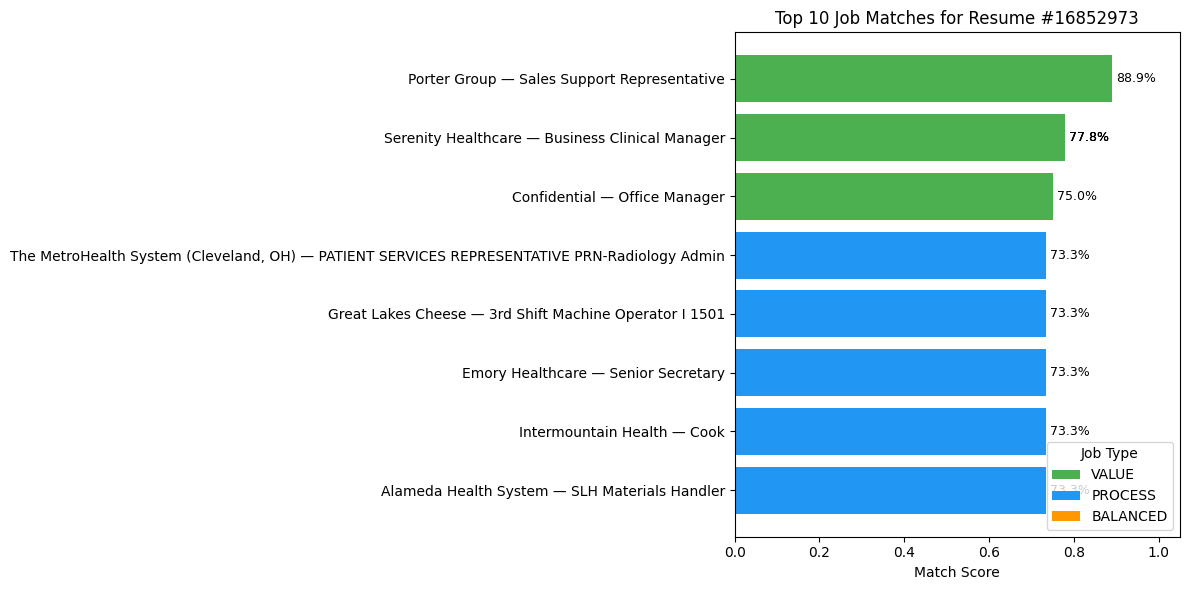


Resume #16852973  |  Category: HR
Resume Type: PROCESS
Skills found: ['data analysis', 'statistics', 'leadership', 'marketing', 'sales', 'customer service', 'accounting', 'budgeting']



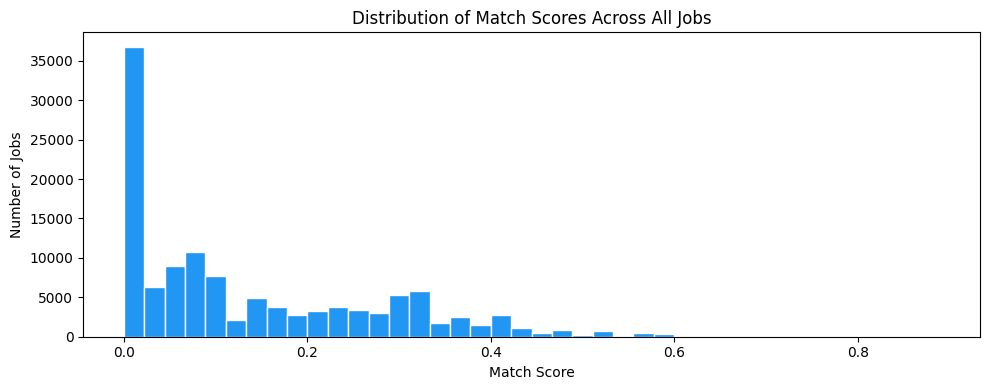

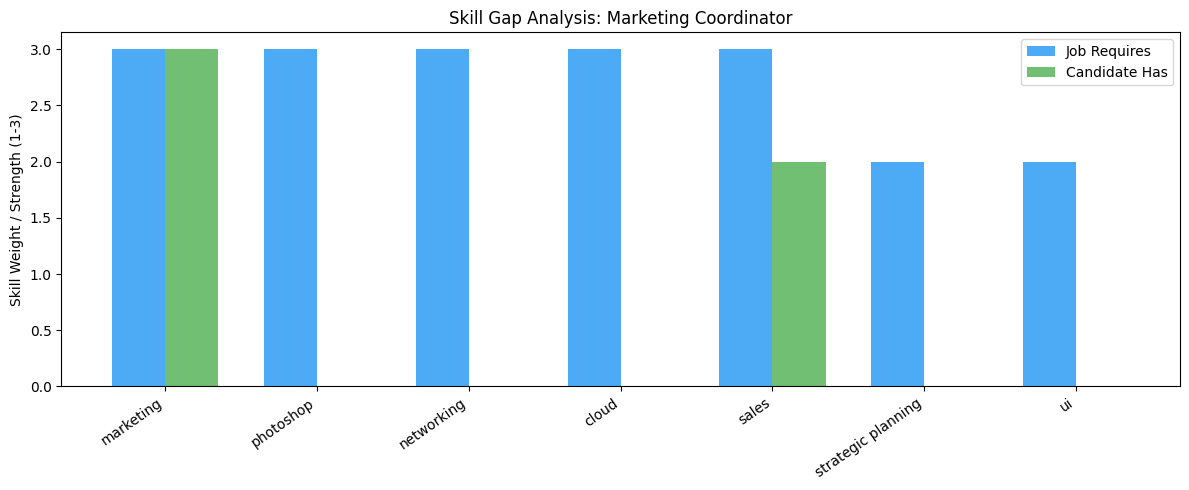


=== VERIFIED SKILL RECOMMENDATIONS ===
                     company_name                                            title job_type  match_score                      top_5_required                            you_have
Pryor Associates Executive Search                P&C Reinsurance Actuary - PR12683  PROCESS       0.9778     [python, sql, machine learning]     [python, sql, machine learning]
Pryor Associates Executive Search                  P&C Assistant Actuary - PR12700  PROCESS       0.9778     [python, sql, machine learning]     [python, sql, machine learning]
Pryor Associates Executive Search                P&C Reinsurance Actuary - PR12683  PROCESS       0.9778     [python, sql, machine learning]     [python, sql, machine learning]
    Delta System & Software, Inc.                    Datawarehouse / ETL Developer  PROCESS       0.9166 [sql, python, excel, data analysis] [sql, python, excel, data analysis]
                  InfoVision Inc.                                     Data 

In [ ]:



# ── CELL 18: Score Distribution ───────────────────────────
def plot_score_distribution(resume_index):
    results = recommend_jobs(resume_index, top_n=len(df_posting_clean))
    plt.figure(figsize=(10, 4))
    plt.hist(results["match_score"], bins=40, color="#2196F3", edgecolor="white")
    plt.title("Distribution of Match Scores Across All Jobs")
    plt.xlabel("Match Score")
    plt.ylabel("Number of Jobs")
    plt.tight_layout()
    plt.show()


# ── CELL 19: Demo — Run Everything ────────────────────────

# --- Auto recommendation (no manual verification) ---
print("\n=== AUTO RECOMMENDATION (Resume #0) ===")
top_matches = recommend_jobs(resume_index=0, top_n=10)
print(top_matches.to_string(index=False))

# --- Filtered by job type ---
print("\n=== VALUE JOBS ONLY ===")
value_matches = recommend_jobs(resume_index=0, top_n=5, job_type_filter="VALUE")
print(value_matches.to_string(index=False))

print("\n=== PROCESS JOBS ONLY ===")
process_matches = recommend_jobs(resume_index=0, top_n=5, job_type_filter="PROCESS")
print(process_matches.to_string(index=False))

# --- Visualize top matches ---
plot_top_jobs(resume_index=0, top_n=10)

# --- Score distribution ---
plot_score_distribution(resume_index=0)

# --- Skill gap for top job ---
plot_skill_gap(resume_index=0, job_index=0)


# ── CELL 20: Manual Skill Verification Example ────────────
# Use this to manually override with TRUE skill levels
# 1=Beginner, 2=Intermediate, 3=Expert

manual_ratings = {
    "python":           3,
    "sql":              3,
    "machine learning": 2,
    "data analysis":    3,
    "excel":            1,
    "communication":    2,
    "statistics":       2,
}

# Get recommendations using verified skills
verified_results = recommend_jobs_verified(
    resume_index=0,
    verified_skills=manual_ratings,
    top_n=10
)

print("\n=== VERIFIED SKILL RECOMMENDATIONS ===")
print(verified_results.to_string(index=False))

# Explanation of scores
print("\n=== SCORING EXPLAINER ===")
print("Match Score = sum(job_weight × candidate_strength) / sum(all job weights)")
print("Top 5 job skills get weight 3 (critical)")
print("Next 5 get weight 2 (important)")
print("Remaining skills get weight 1 (nice to have)")
print("Value↔Value or Process↔Process alignment = +5-10% bonus")
print("Matching all top 5 skills = ~85-90% even if you miss minor ones")


Resume #16852973  |  Category: HR
Resume Type: PROCESS
Skills found: ['data analysis', 'statistics', 'leadership', 'marketing', 'sales', 'customer service', 'accounting', 'budgeting']


Resume #16852973  |  Category: HR
Resume Type: PROCESS
Skills found: ['data analysis', 'statistics', 'leadership', 'marketing', 'sales', 'customer service', 'accounting', 'budgeting']



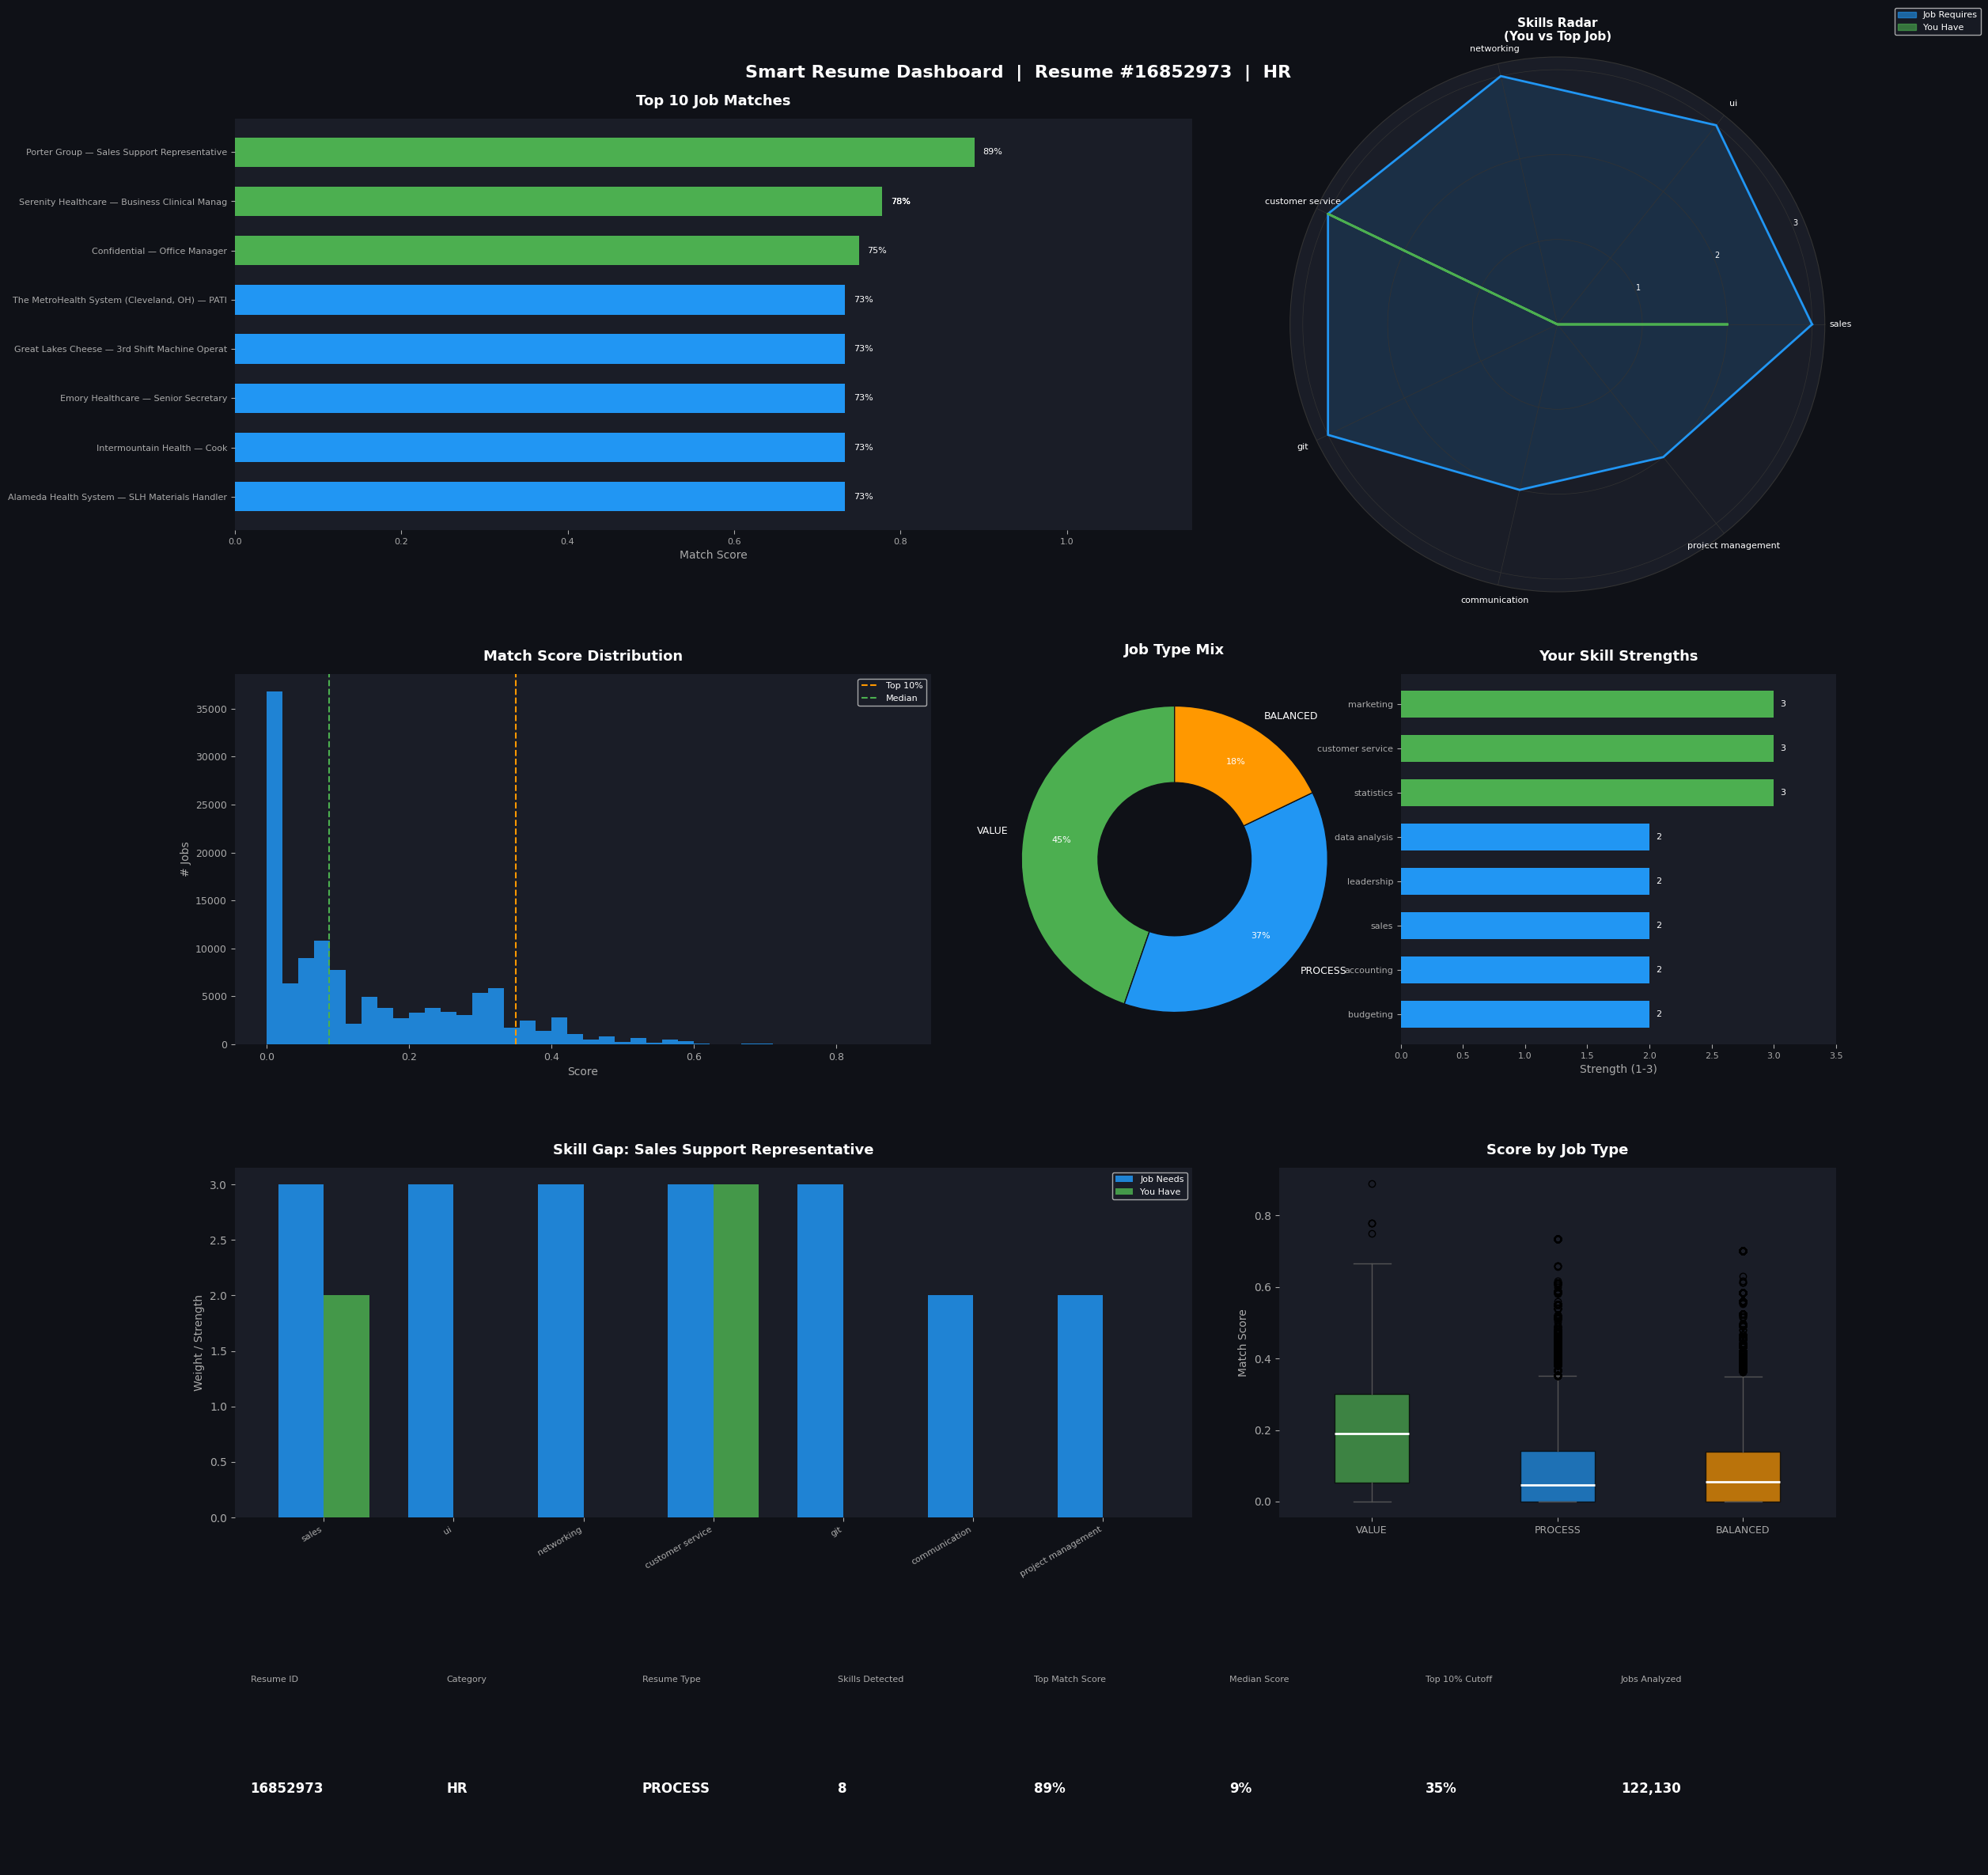

Dashboard saved to Google Drive!


In [ ]:
# ── DASHBOARD: Full Visual Suite ───────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def full_dashboard(resume_index, top_n=10):

    resume_row        = df_resume_clean.iloc[resume_index]
    resume_skill_freq = resume_row["skill_freq"]
    resume_type       = resume_row["resume_type"]
    resume_id         = resume_row["ID"]
    resume_category   = resume_row["Category"]

    # Get recommendations
    top_matches = recommend_jobs(resume_index, top_n=top_n)
    all_matches = recommend_jobs(resume_index, top_n=len(df_posting_clean))

    fig = plt.figure(figsize=(22, 26))
    fig.patch.set_facecolor('#0f1117')

    title_style  = dict(color='white', fontsize=13, fontweight='bold', pad=12)
    label_style  = dict(color='#aaaaaa', fontsize=10)
    JOB_COLORS   = {"VALUE": "#4CAF50", "PROCESS": "#2196F3", "BALANCED": "#FF9800"}

    # ── 1. TOP JOBS BAR CHART (top left) ───────────────────
    ax1 = fig.add_axes([0.05, 0.75, 0.55, 0.20])
    ax1.set_facecolor('#1a1d27')
    labels      = (top_matches["company_name"] + " — " + top_matches["title"]).str[:45]
    bar_colors  = [JOB_COLORS.get(jt, "#999") for jt in top_matches["job_type"]]
    bars        = ax1.barh(labels, top_matches["match_score"], color=bar_colors, edgecolor='none', height=0.6)
    ax1.invert_yaxis()
    ax1.set_xlim(0, 1.15)
    ax1.set_xlabel("Match Score", **label_style)
    ax1.set_title(f"Top {top_n} Job Matches", **title_style)
    ax1.tick_params(colors='#aaaaaa', labelsize=8)
    ax1.spines[:].set_visible(False)
    for bar, score in zip(bars, top_matches["match_score"]):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{score:.0%}", va='center', color='white', fontsize=8)

    # ── 2. RADAR CHART — Resume Skills vs Top Job (top right) ──
    ax2 = fig.add_axes([0.65, 0.72, 0.32, 0.26], polar=True)
    ax2.set_facecolor('#1a1d27')

    top_job       = df_posting_clean[df_posting_clean["title"] == top_matches.iloc[0]["title"]].iloc[0]
    top_job_ws    = top_job["weighted_skills"]
    radar_skills  = [k for k, v in sorted(top_job_ws.items(), key=lambda x: -x[1])][:8]

    if len(radar_skills) >= 3:
        N          = len(radar_skills)
        angles     = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles    += angles[:1]

        job_vals   = [top_job_ws.get(s, 0) for s in radar_skills]
        job_vals  += job_vals[:1]
        cand_vals  = [min(resume_skill_freq.get(s, 0), 3) for s in radar_skills]
        cand_vals += cand_vals[:1]

        ax2.plot(angles, job_vals,  color='#2196F3', linewidth=2)
        ax2.fill(angles, job_vals,  color='#2196F3', alpha=0.15)
        ax2.plot(angles, cand_vals, color='#4CAF50', linewidth=2)
        ax2.fill(angles, cand_vals, color='#4CAF50', alpha=0.25)
        ax2.set_xticks(angles[:-1])
        ax2.set_xticklabels(radar_skills, color='white', fontsize=8)
        ax2.set_yticks([1, 2, 3])
        ax2.set_yticklabels(['1', '2', '3'], color='#555', fontsize=7)
        ax2.tick_params(colors='white')
        ax2.spines['polar'].set_color('#333')
        ax2.set_facecolor('#1a1d27')
        ax2.grid(color='#333', linewidth=0.5)
        ax2.set_title("Skills Radar\n(You vs Top Job)", color='white', fontsize=11, fontweight='bold', pad=15)

        radar_legend = [
            mpatches.Patch(color='#2196F3', alpha=0.6, label='Job Requires'),
            mpatches.Patch(color='#4CAF50', alpha=0.6, label='You Have')
        ]
        ax2.legend(handles=radar_legend, loc='upper right',
                   bbox_to_anchor=(1.3, 1.1), fontsize=8,
                   facecolor='#1a1d27', labelcolor='white', framealpha=0.8)

    # ── 3. SCORE DISTRIBUTION HISTOGRAM (middle left) ──────
    ax3 = fig.add_axes([0.05, 0.50, 0.40, 0.18])
    ax3.set_facecolor('#1a1d27')
    scores = all_matches["match_score"]
    ax3.hist(scores, bins=40, color='#2196F3', edgecolor='none', alpha=0.85)
    ax3.axvline(scores.quantile(0.90), color='#FF9800', linewidth=1.5, linestyle='--', label='Top 10%')
    ax3.axvline(scores.median(),       color='#4CAF50', linewidth=1.5, linestyle='--', label='Median')
    ax3.set_title("Match Score Distribution", **title_style)
    ax3.set_xlabel("Score", **label_style)
    ax3.set_ylabel("# Jobs",  **label_style)
    ax3.tick_params(colors='#aaaaaa', labelsize=9)
    ax3.spines[:].set_visible(False)
    ax3.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white', framealpha=0.8)

    # ── 4. JOB TYPE DONUT (middle center) ──────────────────
    ax4 = fig.add_axes([0.48, 0.49, 0.22, 0.20])
    ax4.set_facecolor('#0f1117')
    type_counts = df_posting_clean["job_type"].value_counts()
    wedge_colors = [JOB_COLORS[t] for t in type_counts.index]
    wedges, texts, autotexts = ax4.pie(
        type_counts,
        labels=type_counts.index,
        colors=wedge_colors,
        autopct='%1.0f%%',
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='#0f1117')
    )
    for t in texts:     t.set_color('white');  t.set_fontsize(9)
    for t in autotexts: t.set_color('white');  t.set_fontsize(8)
    ax4.set_title("Job Type Mix", **title_style)

    # ── 5. CANDIDATE SKILL STRENGTH BAR (middle right) ─────
    ax5 = fig.add_axes([0.72, 0.50, 0.25, 0.18])
    ax5.set_facecolor('#1a1d27')
    if resume_skill_freq:
        sorted_skills = sorted(resume_skill_freq.items(), key=lambda x: -x[1])[:10]
        sk_names  = [s for s, _ in sorted_skills]
        sk_vals   = [min(v, 3) for _, v in sorted_skills]
        bar_cols  = ['#4CAF50' if v == 3 else '#2196F3' if v == 2 else '#FF9800' for v in sk_vals]
        ax5.barh(sk_names, sk_vals, color=bar_cols, edgecolor='none', height=0.6)
        ax5.invert_yaxis()
        ax5.set_xlim(0, 3.5)
        ax5.set_xlabel("Strength (1-3)", **label_style)
        ax5.set_title("Your Skill Strengths", **title_style)
        ax5.tick_params(colors='#aaaaaa', labelsize=8)
        ax5.spines[:].set_visible(False)
        for i, v in enumerate(sk_vals):
            ax5.text(v + 0.05, i, str(v), va='center', color='white', fontsize=8)

    # ── 6. SKILL GAP — TOP JOB (bottom left) ───────────────
    ax6 = fig.add_axes([0.05, 0.27, 0.55, 0.17])
    ax6.set_facecolor('#1a1d27')
    gap_skills   = [k for k, v in sorted(top_job_ws.items(), key=lambda x: -x[1])][:10]
    job_w        = [top_job_ws[s] for s in gap_skills]
    cand_w       = [min(resume_skill_freq.get(s, 0), 3) for s in gap_skills]
    x            = np.arange(len(gap_skills))
    width        = 0.35
    ax6.bar(x - width/2, job_w,  width, label='Job Needs', color='#2196F3', alpha=0.85, edgecolor='none')
    ax6.bar(x + width/2, cand_w, width, label='You Have',  color='#4CAF50', alpha=0.85, edgecolor='none')
    ax6.set_xticks(x)
    ax6.set_xticklabels(gap_skills, rotation=30, ha='right', color='#aaaaaa', fontsize=8)
    ax6.set_ylabel("Weight / Strength", **label_style)
    ax6.set_title(f"Skill Gap: {top_matches.iloc[0]['title'][:40]}", **title_style)
    ax6.tick_params(colors='#aaaaaa')
    ax6.spines[:].set_visible(False)
    ax6.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white', framealpha=0.8)

    # ── 7. SCORE BY JOB TYPE BOXPLOT (bottom right) ────────
    ax7 = fig.add_axes([0.65, 0.27, 0.32, 0.17])
    ax7.set_facecolor('#1a1d27')
    groups     = [all_matches[all_matches["job_type"] == t]["match_score"].values
                  for t in ["VALUE", "PROCESS", "BALANCED"]]
    bp = ax7.boxplot(groups, patch_artist=True, widths=0.4,
                     medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], ["#4CAF50", "#2196F3", "#FF9800"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for element in ['whiskers','caps','fliers']:
        for item in bp[element]: item.set_color('#555')
    ax7.set_xticklabels(["VALUE", "PROCESS", "BALANCED"], color='#aaaaaa', fontsize=9)
    ax7.set_ylabel("Match Score", **label_style)
    ax7.set_title("Score by Job Type", **title_style)
    ax7.tick_params(colors='#aaaaaa')
    ax7.spines[:].set_visible(False)

    # ── 8. STATS SUMMARY CARD (bottom) ─────────────────────
    ax8 = fig.add_axes([0.05, 0.10, 0.90, 0.12])
    ax8.set_facecolor('#1a1d27')
    ax8.axis('off')

    top10_threshold = np.percentile(all_matches["match_score"], 90)
    stats = [
        ("Resume ID",        str(resume_id)),
        ("Category",         resume_category),
        ("Resume Type",      resume_type),
        ("Skills Detected",  str(len(resume_skill_freq))),
        ("Top Match Score",  f"{top_matches['match_score'].iloc[0]:.0%}"),
        ("Median Score",     f"{all_matches['match_score'].median():.0%}"),
        ("Top 10% Cutoff",   f"{top10_threshold:.0%}"),
        ("Jobs Analyzed",    f"{len(all_matches):,}"),
    ]

    for i, (label, value) in enumerate(stats):
        x_pos = 0.01 + i * 0.125
        ax8.text(x_pos, 0.75, label, transform=ax8.transAxes,
                 color='#aaaaaa', fontsize=8, ha='left')
        ax8.text(x_pos, 0.30, value, transform=ax8.transAxes,
                 color='white', fontsize=12, fontweight='bold', ha='left')

    # ── MAIN TITLE ──────────────────────────────────────────
    fig.text(0.5, 0.97, f"Smart Resume Dashboard  |  Resume #{resume_id}  |  {resume_category}",
             ha='center', color='white', fontsize=16, fontweight='bold')

    plt.show()
    print("Dashboard saved to Google Drive!")

# ── RUN ─────────────────────────────────────────────────────
full_dashboard(resume_index=0, top_n=10)

fixing the above